# Model ID (finger) — friction ablation study

Identifies Stribeck friction parameters from step and ramp responses
recorded with and without friction compensation.

## Friction Model

### Mathematical Formulation

Motor and PLA (we are compensating both!) friction in tendon-driven systems exhibits complex nonlinear behavior dominated by stiction at low velocities. We employ a simplified Stribeck friction model for feedforward compensation:

$$\tau_{friction} = F_{max} \cdot \exp\left(-\left(\frac{\dot{q}}{v_{lim}}\right)^2\right) \cdot \text{sign}(\tau_{cmd})$$

where $F_{max}$ is the maximum static friction torque, $v_{lim}$ is the Stribeck velocity parameter, $\dot{q}$ is the motor velocity, and $\tau_{cmd}$ is the commanded torque.

### Physical Interpretation

The exponential term creates a velocity-dependent gain that naturally attenuates with increasing speed. At rest, full compensation provides a directional "kick" to overcome stiction. As velocity increases, compensation gradually fades, becoming negligible at high speeds where viscous friction is less detrimental to tracking performance.

This self-regulating behavior acts as an "intelligent dither" that applies torque only when needed and in the commanded direction, addressing motor stiction and low-velocity stick-slip without introducing continuous high-frequency oscillations. Interestingly, this approach is bio-inspired by physiological tremor observed in human hands during grasping and manipulation tasks. Healthy human subjects exhibit inherent oscillatory motor output in the 8-12 Hz range during force control and isometric grasping, arising from mechanical resonance, motor unit firing properties, and central nervous system activity. This natural tremor has been shown to facilitate smooth motor control and may serve a functional role in overcoming static friction in biological musculoskeletal systems. Our velocity-dependent friction compensation mimics this biological strategy—providing just enough perturbation to overcome stiction while naturally decaying during motion, analogous to how physiological tremor aids human motor control without causing instability.

The parameter $F_{max}$ is determined by observing motor wobbling without compensation - when static friction exceeds the virtual spring restoring force. Overestimating $F_{max}$ is acceptable due to velocity-dependent attenuation: excess compensation at zero velocity naturally decays once motion initiates.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os, sys

sys.path.insert(0, '..')
from plot_config import draw_radar, COLORS, FIG_W_SINGLE, FIG_W_DOUBLE, set_font_size
FIG_W = 10   # inches — change freely

FIG_H = 6    # inches — change freely

GRID = False
FONT_SIZE = 18  # pt — change to rescale all text uniformly
set_font_size(FONT_SIZE)
plt.rcParams['savefig.bbox'] = 'tight'
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
def load_experiment_data(experiment_name):
    """
    Load experiment data from CSV file.
    
    Parameters:
    -----------
    experiment_name : str
        Name of the experiment (e.g., 'step_with_friction')
    
    Returns:
    --------
    DataFrame : Loaded data with columns [Time_s, Ref_MCP_deg, Ref_PIP_deg, MCP_deg, PIP_deg]
    """
    filepath = os.path.join('outputs/friction_ablation', f'{experiment_name}.csv')
    df = pd.read_csv(filepath)
    print(f"Data loaded from {filepath}")
    print(f"  Shape: {df.shape}")
    print(f"  Duration: {df['Time_s'].max():.2f} s")
    return df

In [3]:
def plot_comparison(data_with_friction, data_no_friction, joint='MCP',
                    trajectory_type='Step', ref_column='Ref_MCP_deg', actual_column='MCP_deg',
                    ylabel=r'Angle ($^\circ$)', colors=None):
    if colors is None:
        colors = {'with_friction': '#4DBBD5', 'without_friction': '#E64B35'}

    # ---- size / aspect for THIS graph only ----
    W_IN   = 8.5 * 0.65
    ASPECT = 5.15 / 9
    H_IN   = W_IN * ASPECT
    fig, ax = plt.subplots(figsize=(W_IN, H_IN))

    ax.plot(data_with_friction['Time_s'], data_with_friction[ref_column],
            '--', color='gray', label='Ref.', zorder=1)
    ax.plot(data_with_friction['Time_s'], data_with_friction[actual_column],
            color=colors['with_friction'], label='w/ Fric. Comp.', zorder=3)
    ax.plot(data_no_friction['Time_s'], data_no_friction[actual_column],
            color=colors['without_friction'], label='w/o Fric. Comp.', zorder=2)

    ax.set_xlabel('Time (s)')
    ax.set_ylabel(ylabel)
    ax.legend()
    fig.tight_layout()
    os.makedirs(os.path.join('outputs', 'friction_ablation'), exist_ok=True)
    fig.savefig(os.path.join('outputs', 'friction_ablation', f'{joint}_{trajectory_type.lower()}.pdf'))
    plt.show()

## Load Experimental Data

Load all four experiments:
- Step with friction compensation
- Step without friction compensation
- Ramp with friction compensation
- Ramp without friction compensation

In [4]:
# Load step response data
step_with_friction = load_experiment_data('step_with_friction')
step_no_friction = load_experiment_data('step_no_friction')

print()

Data loaded from outputs/friction_ablation\step_with_friction.csv
  Shape: (5398, 5)
  Duration: 6.00 s
Data loaded from outputs/friction_ablation\step_no_friction.csv
  Shape: (5399, 5)
  Duration: 6.00 s



In [5]:
# Load ramp response data
ramp_with_friction = load_experiment_data('ramp_with_friction')
ramp_no_friction = load_experiment_data('ramp_no_friction')

Data loaded from outputs/friction_ablation\ramp_with_friction.csv
  Shape: (5399, 5)
  Duration: 6.00 s
Data loaded from outputs/friction_ablation\ramp_no_friction.csv
  Shape: (5398, 5)
  Duration: 6.00 s


## Plot 1: Step Response - MCP Joint

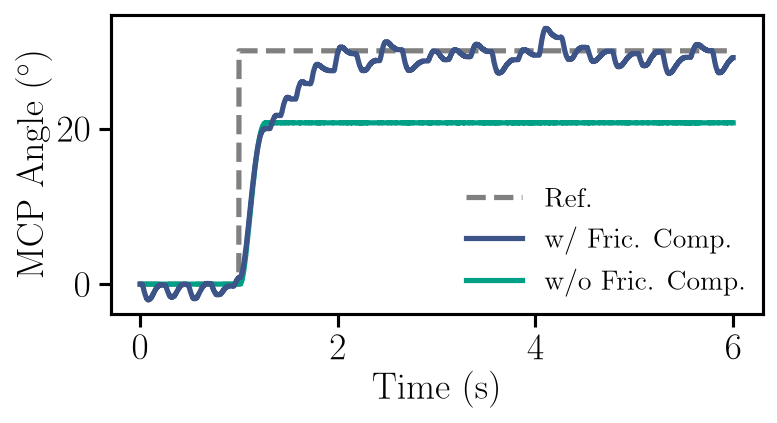

In [6]:
# MCP colors: C0 (Cyan) w/ friction, C3 (Navy) w/o friction
mcp_colors = {'with_friction': 'C3', 'without_friction': 'C2'}

plot_comparison(step_with_friction, step_no_friction, 
                joint='MCP', trajectory_type='Step',
                ref_column='Ref_MCP_deg', actual_column='MCP_deg',
                ylabel=r'MCP Angle ($^\circ$)',
                colors=mcp_colors)

## Plot 2: Step Response - PIP Joint

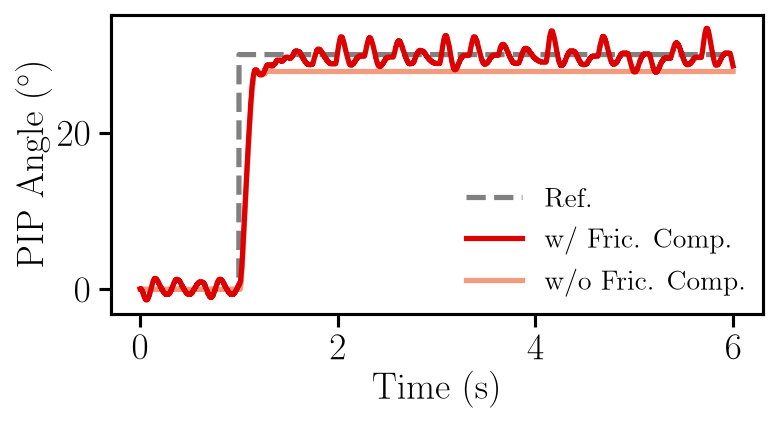

In [7]:
# PIP colors: C1 (Red) w/ friction, C8 (Brown) w/o friction
pip_colors = {'with_friction': 'C7', 'without_friction': 'C4'}

plot_comparison(step_with_friction, step_no_friction, 
                joint='PIP', trajectory_type='Step',
                ref_column='Ref_PIP_deg', actual_column='PIP_deg',
                ylabel=r'PIP Angle ($^\circ$)',
                colors=pip_colors)

## Plot 3: Ramp Response - MCP Joint

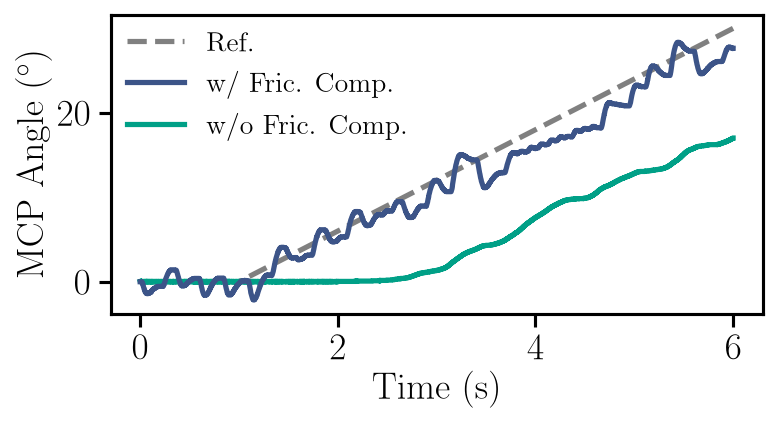

In [8]:
# MCP colors: C0 (Cyan) w/ friction, C3 (Navy) w/o friction
mcp_colors = {'with_friction': 'C3', 'without_friction': 'C2'}

plot_comparison(ramp_with_friction, ramp_no_friction, 
                joint='MCP', trajectory_type='Ramp',
                ref_column='Ref_MCP_deg', actual_column='MCP_deg',
                ylabel=r'MCP Angle ($^\circ$)',
                colors=mcp_colors)

## Plot 4: Ramp Response - PIP Joint

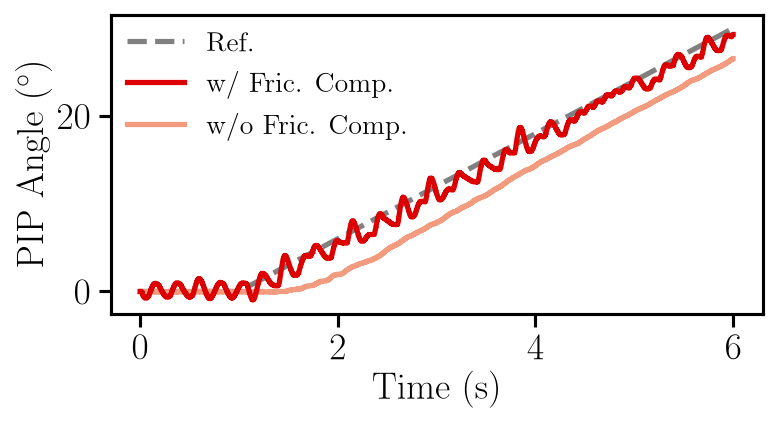

In [9]:
# PIP colors: C1 (Red) w/ friction, C8 (Brown) w/o friction
pip_colors = {'with_friction': 'C7', 'without_friction': 'C4'}

plot_comparison(ramp_with_friction, ramp_no_friction, 
                joint='PIP', trajectory_type='Ramp',
                ref_column='Ref_PIP_deg', actual_column='PIP_deg',
                ylabel=r'PIP Angle ($^\circ$)',
                colors=pip_colors)